<h1>Задание 3 </h1>

<b>Найти минимальное остовное дерево</b> для графа из файла Graph2.csv >

<h3>Записываем файл из csv в DataFrame</h3>

In [103]:
import pandas as pd

link = "C:/Users/User/Desktop/Graph2.csv"

df = pd.read_csv(link, names = ['from', 'to', 'weights'])
df.head()

,from,to,weights
0,41,70,3
1,41,25,1
2,11,27,7
3,11,82,10
4,91,38,5


<h3>Реализация алгоритма поиска минимального оставного дерева (алгоритм Краскала)</h3>

In [106]:

import heapq
from collections import defaultdict

def create_spanning_tree(graph, starting_vertex):
    mst = defaultdict(set)
    visited = set([starting_vertex])
    edges = [
        (cost, starting_vertex, to)
        for to, cost in graph[starting_vertex]
    ]
    heapq.heapify(edges)

    while edges:
        cost, frm, to = heapq.heappop(edges)
        if to not in visited:
            visited.add(to)
            mst[frm].add(to)
            for to_next, cost2 in graph[to]:
                if to_next not in visited:
                    heapq.heappush(edges, (cost2, to, to_next))

    return mst

<h3>
    Записываем граф в виде словаря
</h3>
<b>Вид словаря:</b><br> Ключ - вершина <br> Значение - кортеж из (смежная вершина, вес)



In [109]:
graph = {}

for i in range(len(df)):
    fr, to, cost = df.iloc[i].values
    
    if fr not in graph:
        graph[fr] = []
    graph[fr].append((to,cost))
    
    # if to not in graph:
    #     graph[to] = []
    # graph[to].append((fr,cost))

len(graph)

100

<h3>Применив алгоритм получили минимальное оставное дерево в переменной mst</h3>

In [112]:
mst = create_spanning_tree(graph, 1)

<h3>Изобразим полученное минимальное оставное дерево</h3>
Для этого запишим полученные ребра и вершины в соответствующие переменные <b>nodes</b>, <b>edges</b>

In [115]:
#Ребра
edges = []

for k , v in mst.items():
    for i in v:
        edges.append((k,i)) 

#Вершины
nodes = [i for i in range(1, 101)]

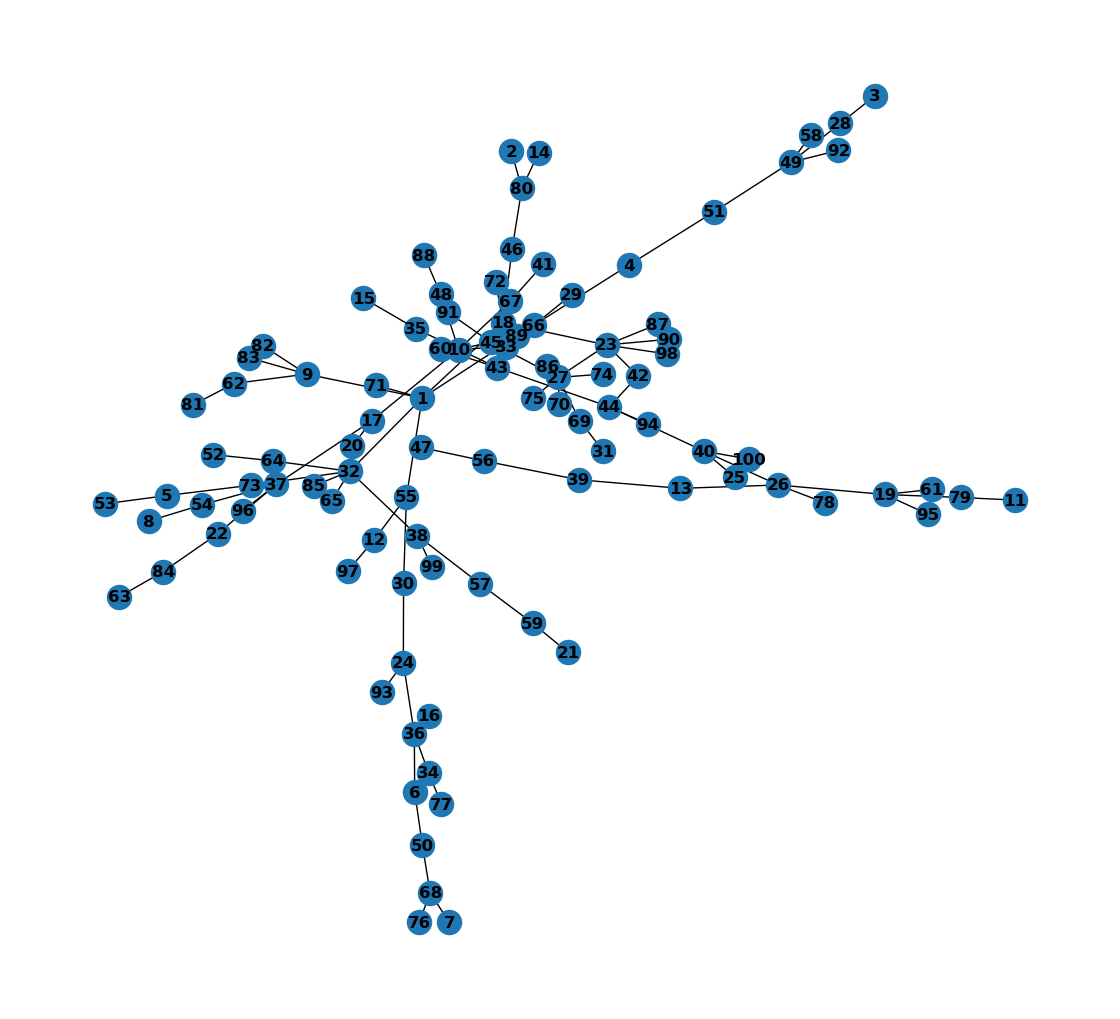

In [117]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize = (11,10))
nx.draw(G, with_labels = True, font_weight = 'bold')
plt.show()

<h2>Посчитаем сумму весов</h2>
Для этого запишем изначальны граф в виде матрицы и посчитаем веса ребер полученных в оставном дереве

In [119]:
import math
import numpy as np 

gr = np.array([np.array([math.inf for _ in range(100)]) for i in range(100)])

for i in range(len(gr)):
    gr[i][i] = 0

values = df.values
for i in range(len(values)):
    fr, to,cost = values[i]
    gr[fr-1][to-1] = cost
    gr[to-1][fr-1] = cost

summa = 0
for edge in edges:
    fr,to = edge
    summa += gr[fr-1][to-1]


print(f'Summa grapha equal {int(summa)}')

Summa grapha equal 298


<h2>Мы получили граф весом 298!</h2>

In [121]:
summa_graph = 0
for i in range(len(gr)):
    for j in range(len(gr[i])):
        if gr[i][j] != math.inf:
            summa_graph += gr[i][j]
print('Сумма изначального графа составляла {}'.format(int(summa_graph)))

Сумма изначального графа составляла 29738
